In [1]:
# Skipped in CI: Colab/bootstrap dependency install cell.


# セグメント解析: 可視化

`SegmentTable` は豊富な描画機能を提供します。特に `overlay_spectra()` は、複数セグメント間のスペクトルを美しく比較するために最適化されています。

ここでも区間そのものは `gwpy.segments.Segment`、重ね描きするスペクトルは GWpy の `FrequencySeries` を使います。gwexpy はそれらの GWpy 基盤クラスを `SegmentTable` にまとめ、可視化や色分け、俯瞰レイアウトを表処理として追加しています。基礎関係は [SegmentTable: 基本](intro_segment_table.ipynb) を参照してください。


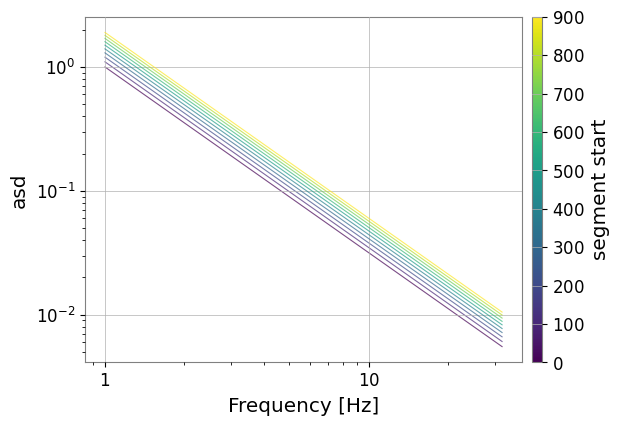

In [2]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import warnings

with warnings.catch_warnings():
    warnings.simplefilter('ignore')

    import numpy as np
    from gwpy.frequencyseries import FrequencySeries
    from gwpy.segments import Segment

    from gwexpy.table import SegmentTable

    def make_fs(i):
        f = np.linspace(1, 32, 256)
        data = (1.0/(f**1.5)) * (1.0 + i*0.1)
        return FrequencySeries(data, frequencies=f)

    segs = [Segment(i*100, i*100+100) for i in range(10)]
    st = SegmentTable.from_segments(segs, snr=np.random.uniform(5, 20, 10))
    st.add_series_column("asd", data=[make_fs(i) for i in range(10)], kind="frequencyseries")

    # 1. Overlay spectra graded by start time (default)
    plot = st.overlay_spectra("asd", color_by="t0")
    plot


## メタデータ列による色付け

任意の数値メタデータ（例：SNR）に基づいて、各行のラインに色をつけることができます。

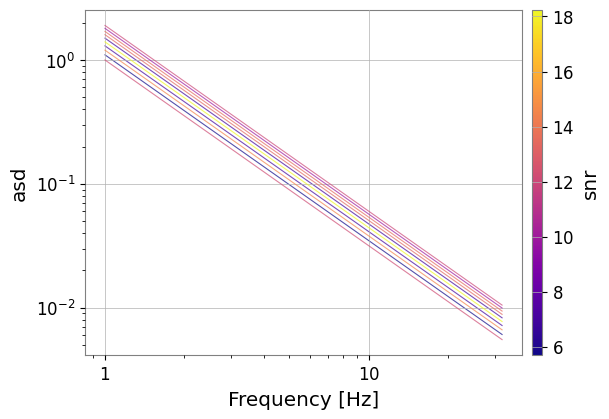

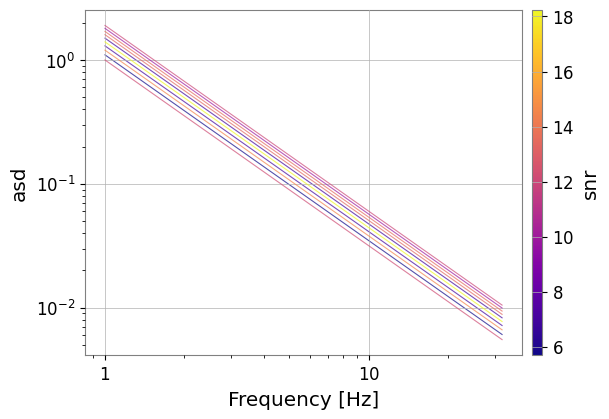

In [3]:
plot = st.overlay_spectra("asd", color_by="snr", cmap="plasma")
plot

## 俯瞰レイアウト

`segments()` を使用して、テーブルの時間的なレイアウトを確認します。

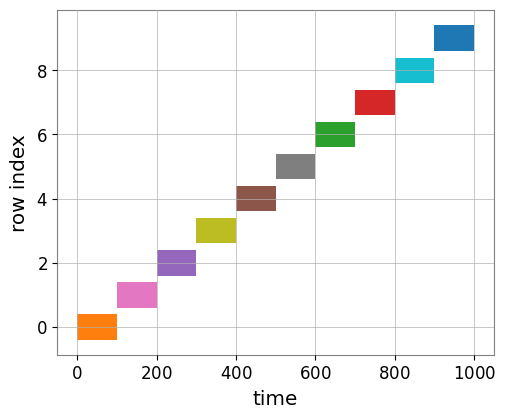

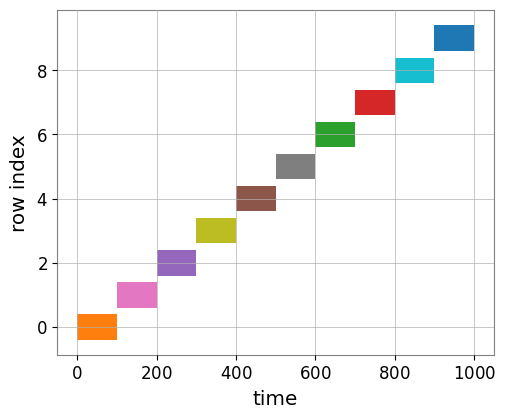

In [4]:
st.segments(color="snr")